## describe data ##

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.utils import shuffle 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from pandas.plotting import scatter_matrix
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBRegressor
from sklearn.metrics import accuracy_score


In [2]:
data = pd.read_csv("data/Breast_Cancer.csv")
data.head()

,Age,Race,Marital Status,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


In [3]:
data.shape

(4024, 15)

In [4]:
data.describe()

,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months
count,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000
mean,53.972167,30.473658,14.357107,4.158052,71.297962
std,8.963134,21.119696,8.099675,5.109331,22.921430
min,30.000000,1.000000,1.000000,1.000000,1.000000
25%,47.000000,16.000000,9.000000,1.000000,56.000000
50%,54.000000,25.000000,14.000000,2.000000,73.000000
75%,61.000000,38.000000,19.000000,5.000000,90.000000
max,69.000000,140.000000,61.000000,46.000000,107.000000


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     4024 non-null   int64 
 1   Race                    4024 non-null   object
 2   Marital Status          4024 non-null   object
 3   N Stage                 4024 non-null   object
 4   6th Stage               4024 non-null   object
 5   differentiate           4024 non-null   object
 6   Grade                   4024 non-null   object
 7   A Stage                 4024 non-null   object
 8   Tumor Size              4024 non-null   int64 
 9   Estrogen Status         4024 non-null   object
 10  Progesterone Status     4024 non-null   object
 11  Regional Node Examined  4024 non-null   int64 
 12  Reginol Node Positive   4024 non-null   int64 
 13  Survival Months         4024 non-null   int64 
 14  Status                  4024 non-null   object
dtypes: i

In [6]:
data['A Stage'].value_counts()

A Stage
Regional    3932
Distant       92
Name: count, dtype: int64

## plt data ##

* Patient Status by Tumor Size Groups (0–120)

In [7]:
bins = list(range(0, 105, 5))
labels = [f"{i}-{i+5}" for i in bins[:-1]]

# Create a temporary DataFrame for plotting
plot_data = data.copy()
plot_data['Tumor Size Group'] = pd.cut(plot_data['Tumor Size'], bins=bins, labels=labels, right=False)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_21704\111882271.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tumor_group_status_counts = plot_data.groupby(['Tumor Size Group', 'Status']).size().reset_index(name='Count')


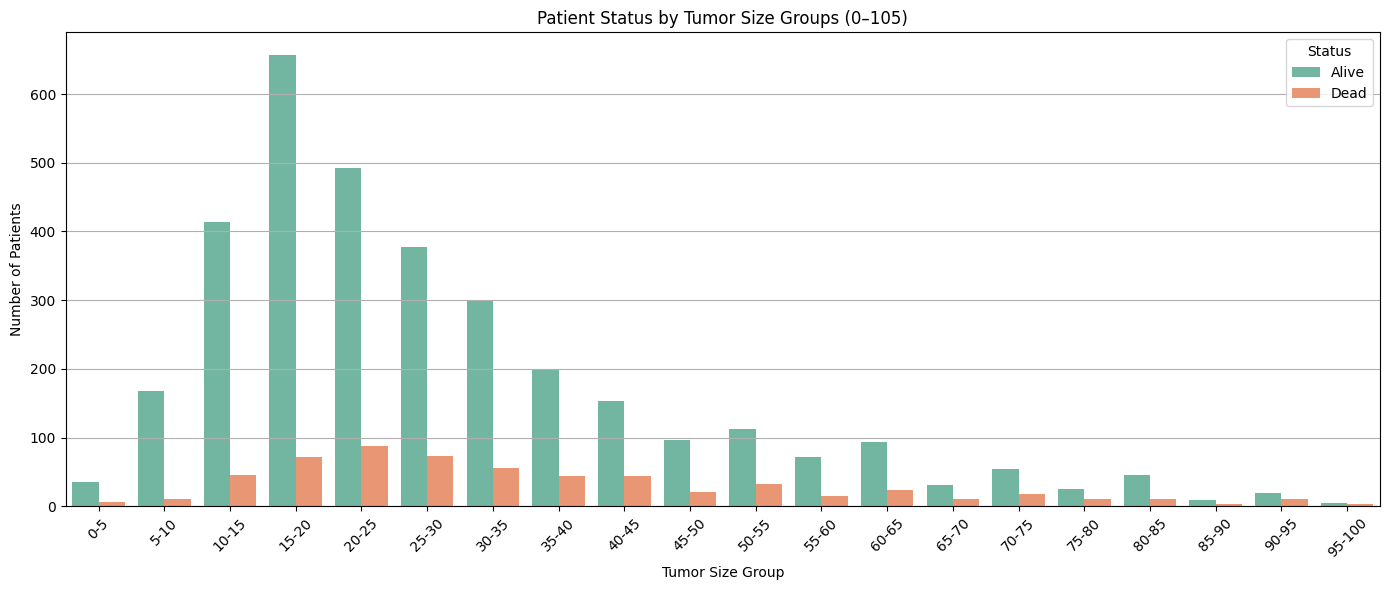

In [8]:
# Count by Tumor Size Group and Status
tumor_group_status_counts = plot_data.groupby(['Tumor Size Group', 'Status']).size().reset_index(name='Count')

plt.figure(figsize=(14, 6))
sns.barplot(data=tumor_group_status_counts, x='Tumor Size Group', y='Count', hue='Status', palette='Set2')

plt.title('Patient Status by Tumor Size Groups (0–105)')
plt.xlabel('Tumor Size Group')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


* Patient Status by Age Group

In [9]:
bins = list(range(20, 90, 5))
labels = [f"{i}-{i+5}" for i in bins[:-1]] 

plot_data = data.copy()
plot_data['Age Group'] = pd.cut(plot_data['Age'], bins=bins, labels=labels, right=False)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_21704\736074104.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_status_counts = plot_data.groupby(['Age Group', 'Status']).size().unstack(fill_value=0)


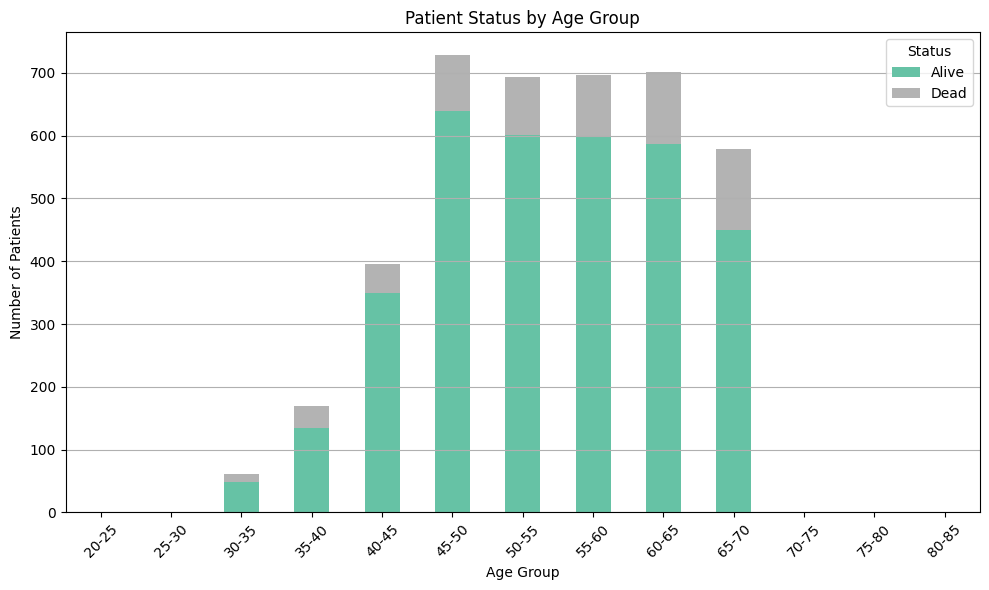

In [10]:
# Count Alive/Dead in each age group
age_status_counts = plot_data.groupby(['Age Group', 'Status']).size().unstack(fill_value=0)

age_status_counts.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set2')

plt.title('Patient Status by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.legend(title='Status')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y')
plt.show()

In [11]:
max_months = data['Survival Months'].max()
bins = list(range(0, int(max_months + 5), 5))
labels = [f"{i}-{i+5}" for i in bins[:-1]]

plot_data = data.copy()
plot_data['Survival Group'] = pd.cut(plot_data['Survival Months'], bins=bins, labels=labels, right=False)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21704\1080579892.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_group_counts = plot_data.groupby(['Survival Group', 'Status']).size().reset_index(name='Count')


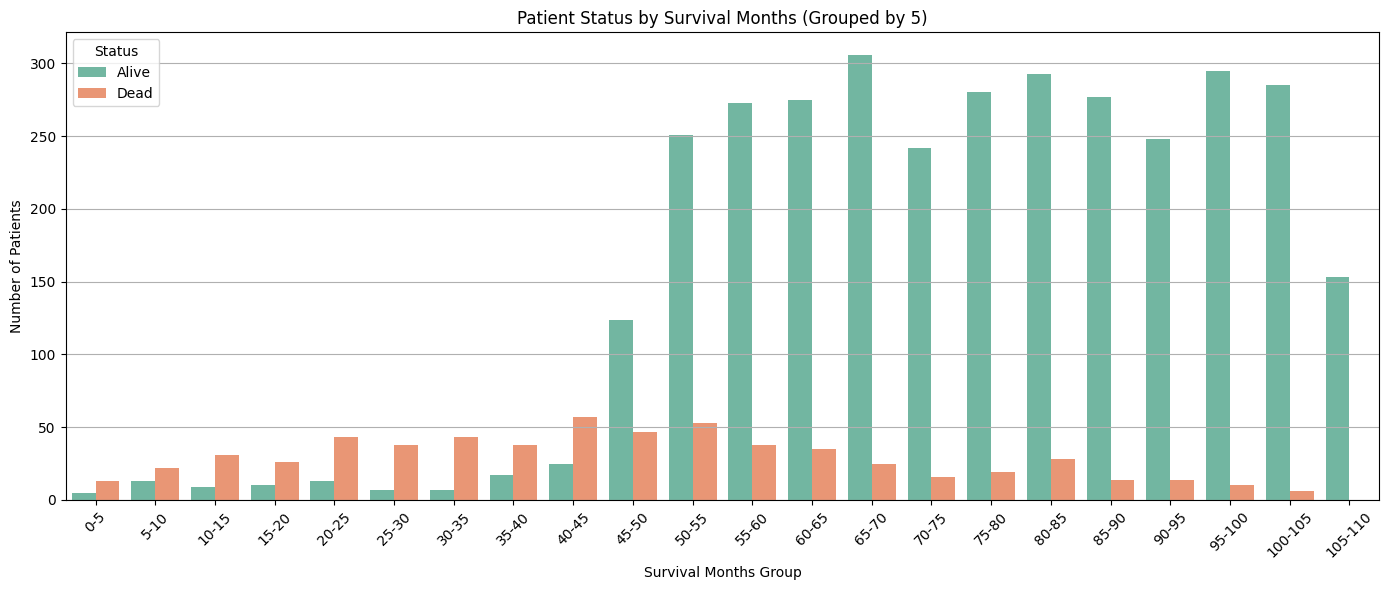

In [12]:
# Count records by Survival Group and Status
survival_group_counts = plot_data.groupby(['Survival Group', 'Status']).size().reset_index(name='Count')

plt.figure(figsize=(14, 6))
sns.barplot(data=survival_group_counts, x='Survival Group', y='Count', hue='Status', palette='Set2')

plt.title('Patient Status by Survival Months (Grouped by 5)')
plt.xlabel('Survival Months Group')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

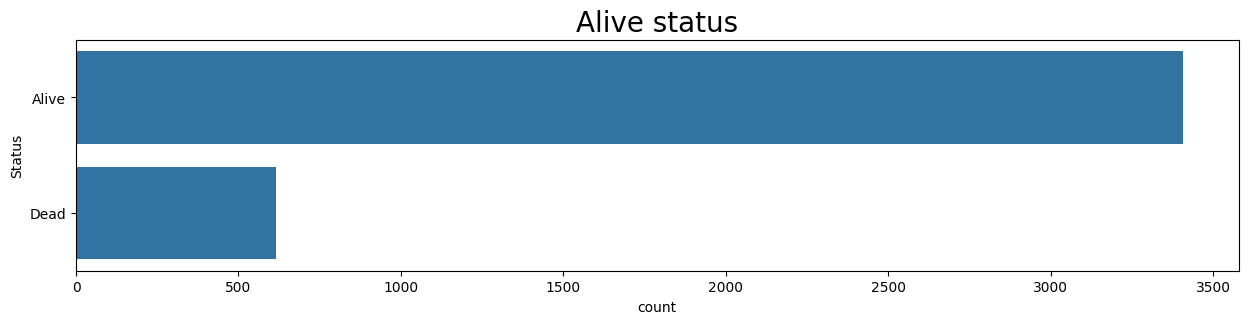

In [13]:
plt.figure(figsize = (15, 3))
sns.countplot(y = data.Status)
plt.title("Alive status", fontsize = 20)
plt.show()

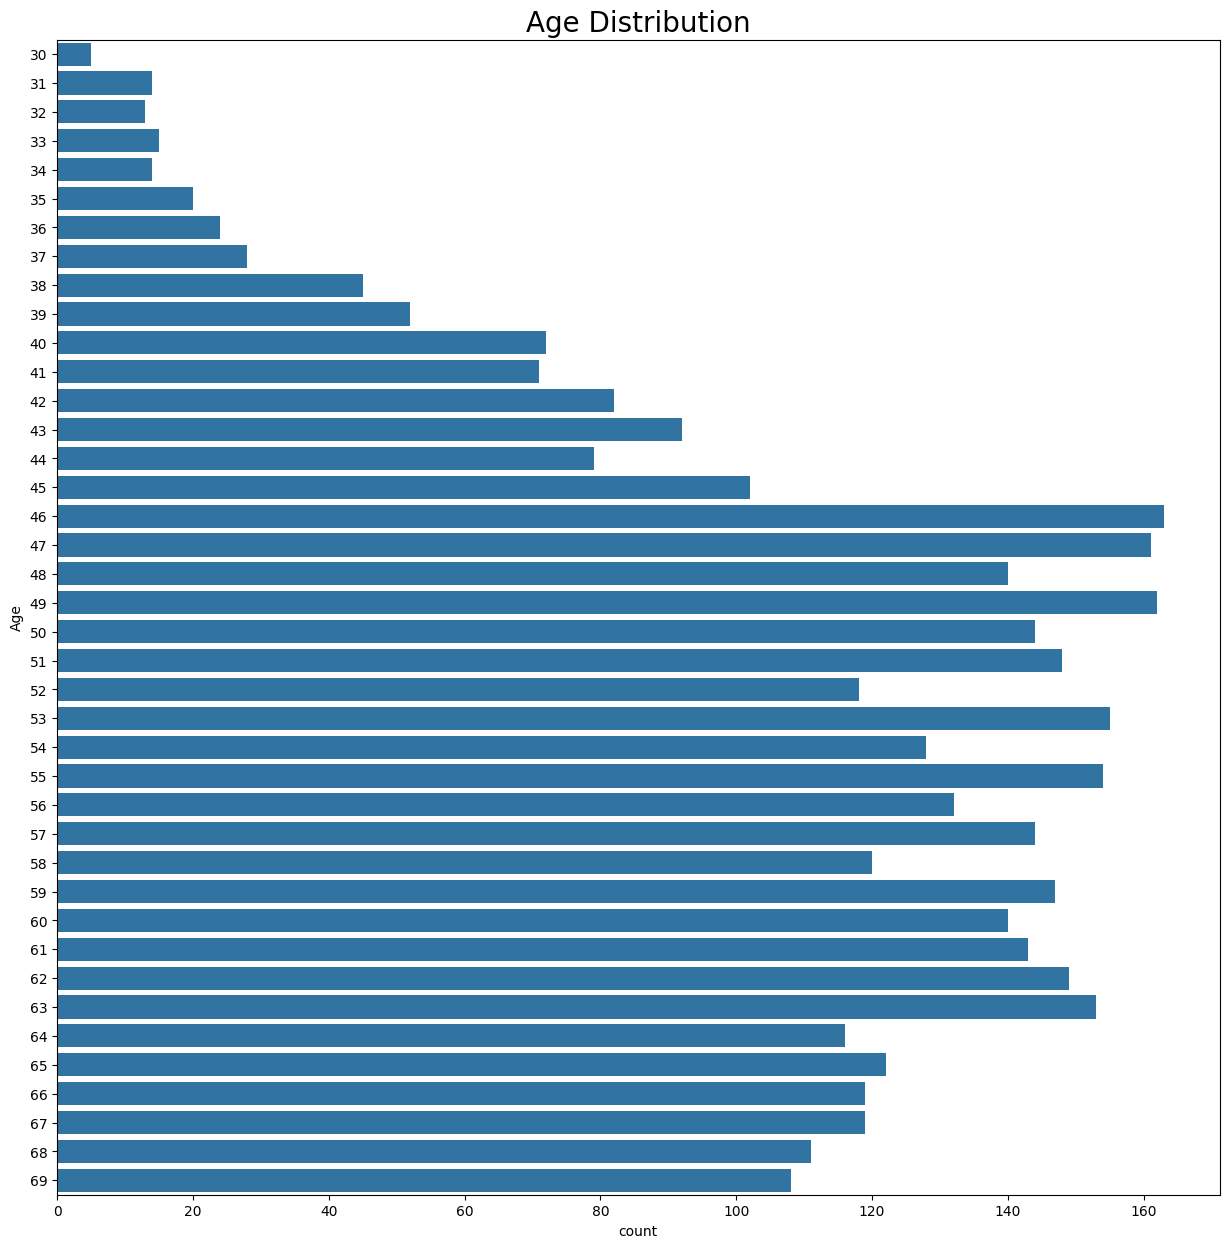

In [14]:
plt.figure(figsize = (15, 15))
sns.countplot(y = data.Age)
plt.title("Age Distribution", fontsize = 20)
plt.show()

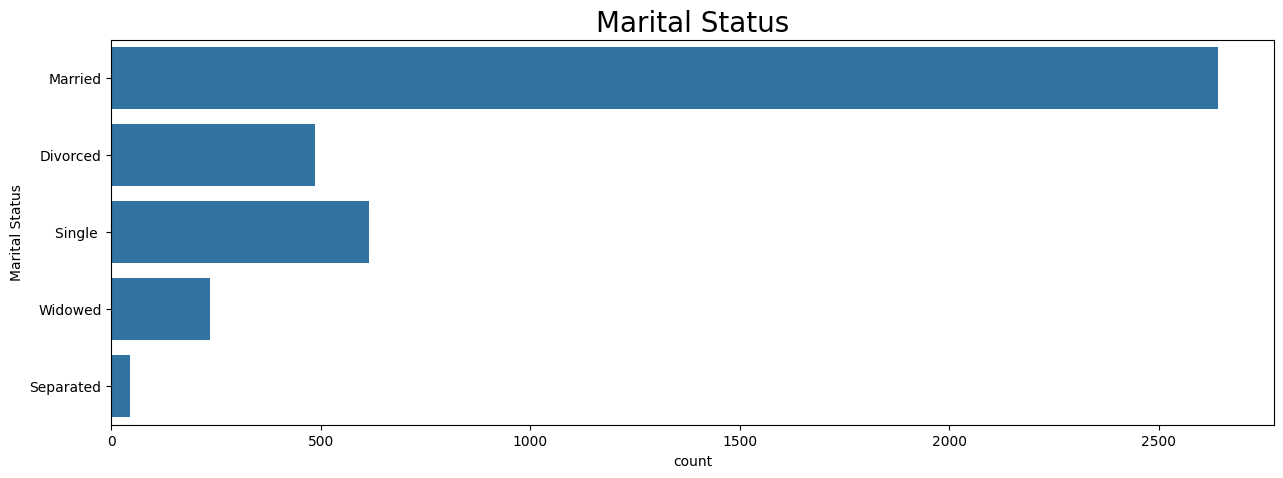

In [15]:
plt.figure(figsize = (15, 5))
sns.countplot(y = data["Marital Status"])
plt.title("Marital Status", fontsize = 20)
plt.show()

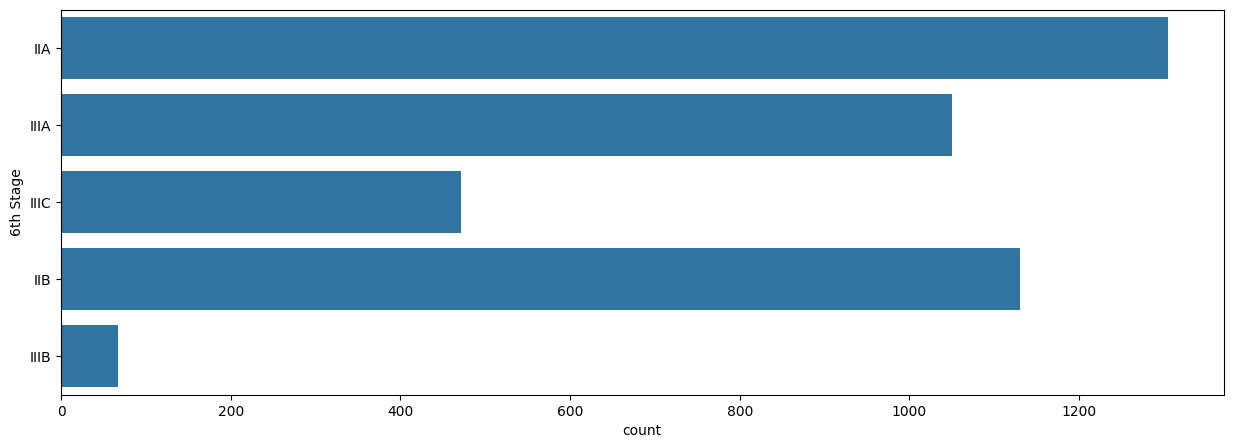

In [16]:
plt.figure(figsize = (15, 5))
sns.countplot(y = data["6th Stage"])
plt.show()

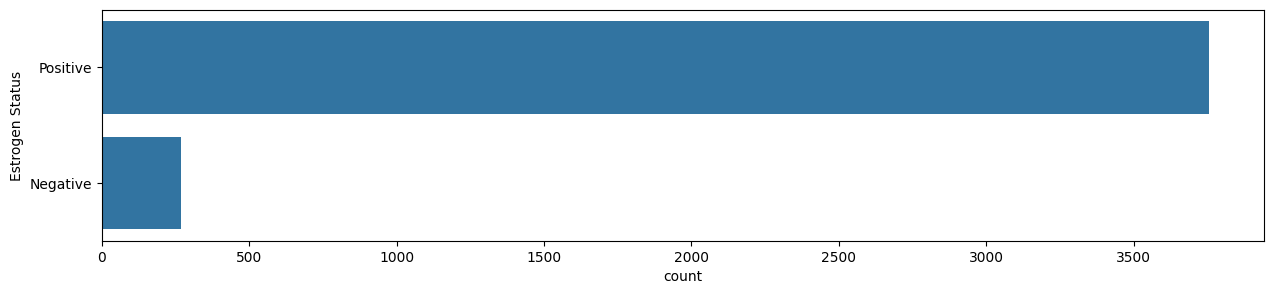

In [17]:
plt.figure(figsize = (15, 3))
sns.countplot(y = data["Estrogen Status"])
plt.show()

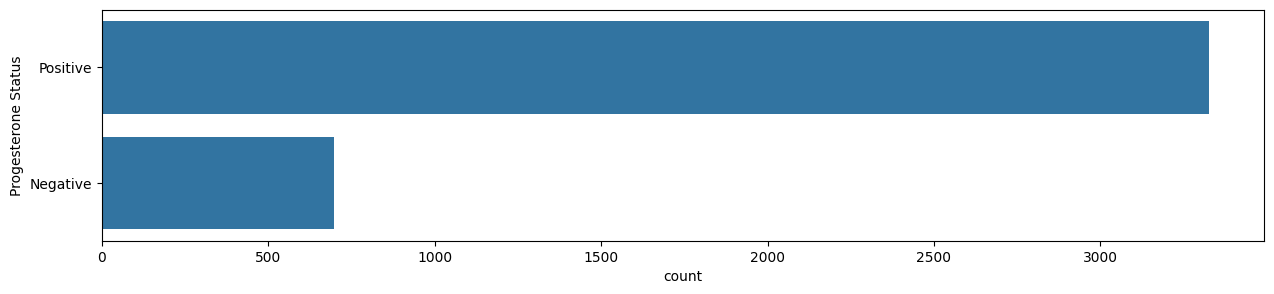

In [18]:
plt.figure(figsize = (15, 3))
sns.countplot(y = data["Progesterone Status"])
plt.show()

## describe unique data ##

In [19]:
data.nunique()

Age                        40
Race                        3
Marital Status              5
N Stage                     3
6th Stage                   5
differentiate               4
Grade                       4
A Stage                     2
Tumor Size                110
Estrogen Status             2
Progesterone Status         2
Regional Node Examined     54
Reginol Node Positive      38
Survival Months           107
Status                      2
dtype: int64

##  find missing value  ##

 total missing value is : Age                       0
Race                      0
Marital Status            0
N Stage                   0
6th Stage                 0
differentiate             0
Grade                     0
A Stage                   0
Tumor Size                0
Estrogen Status           0
Progesterone Status       0
Regional Node Examined    0
Reginol Node Positive     0
Survival Months           0
Status                    0
dtype: int64


<Axes: >

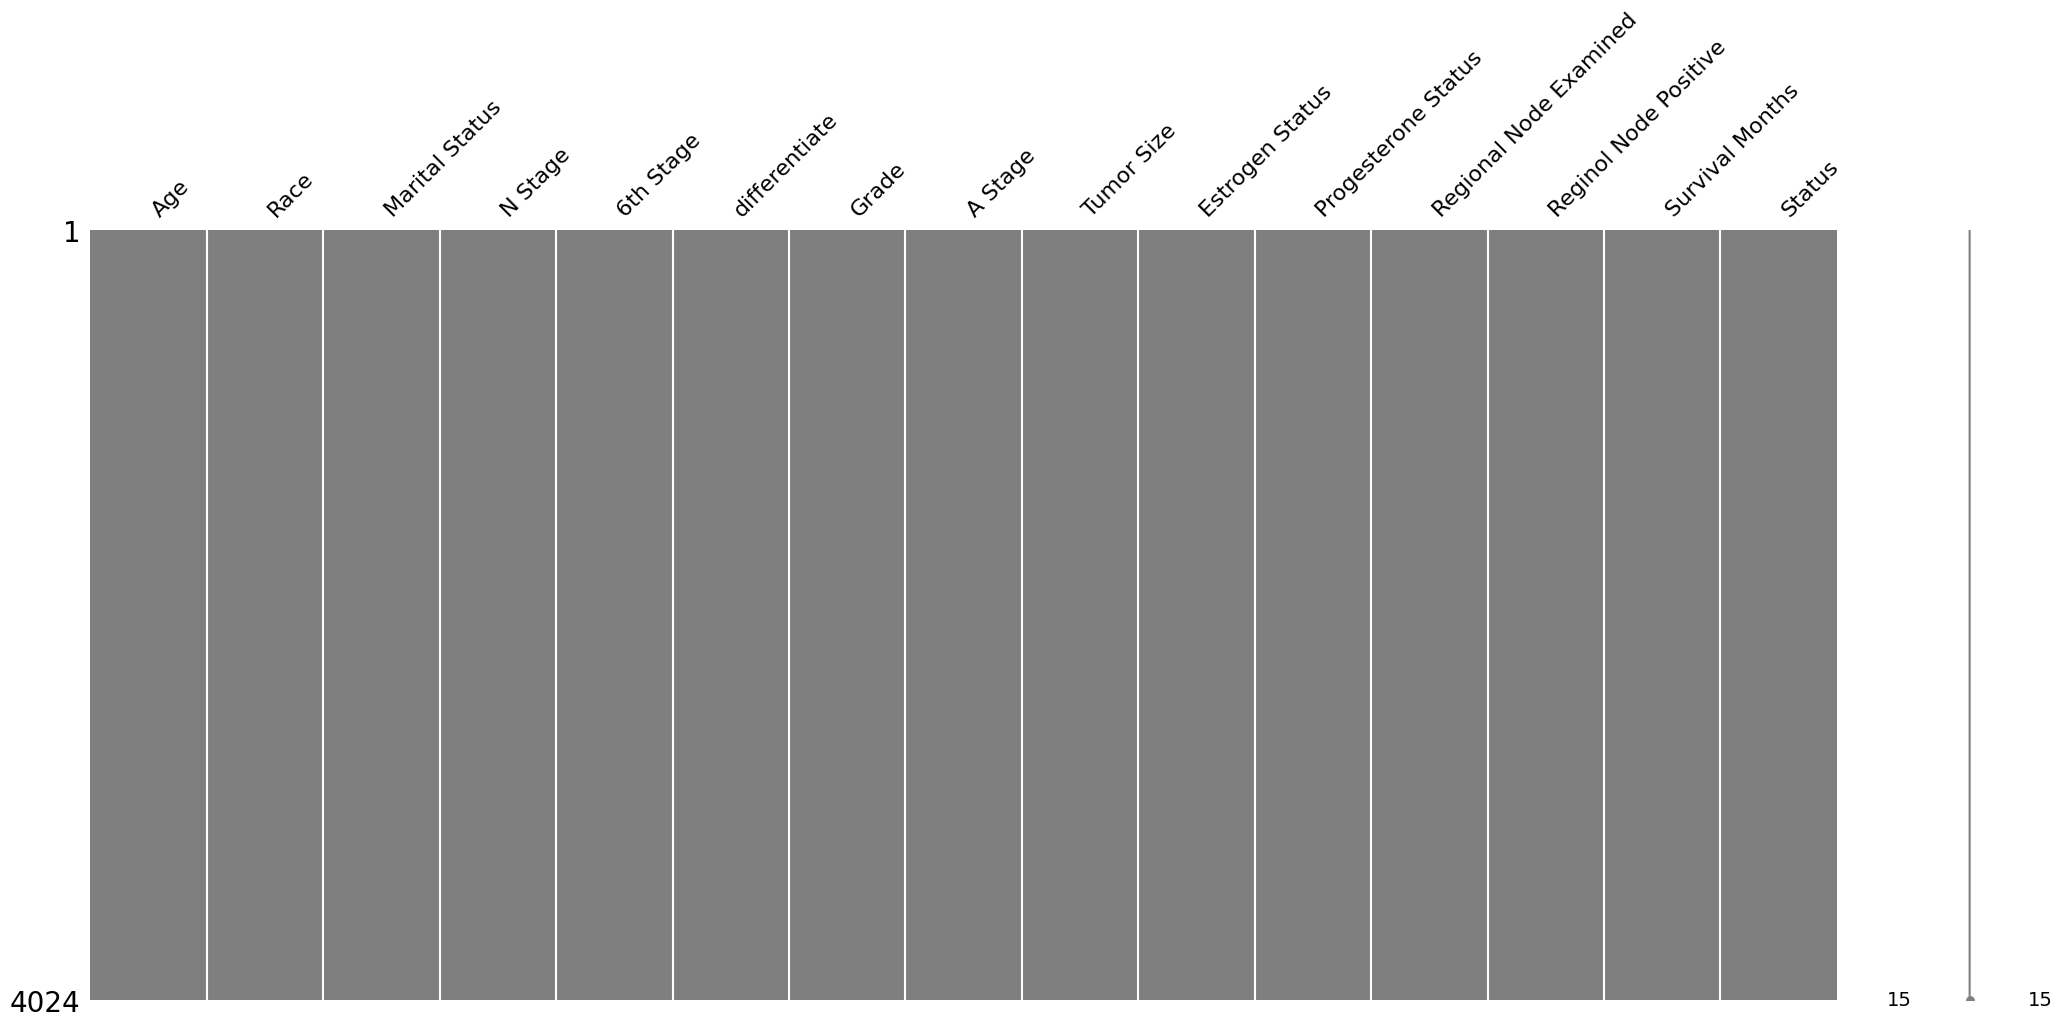

In [20]:
df = pd.DataFrame(data)
missing_value = df.isnull().sum()
print(" total missing value is :", missing_value)

msno.matrix(data, color = (0.5, 0.5, 0.5))

## Shuffling and split the data


In [21]:
shuffled_data = shuffle(data, random_state = 42)
X = shuffled_data.drop(['Status'], axis = 1)
Y = shuffled_data['Status']

## split data

In [22]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

In [23]:
print("The size of the input train data is: {}".format(X_train.shape))
print("The size of the output train data is: {}".format(Y_train.shape))
print("The size of the input test data is: {}".format(X_test.shape))
print("The size of the output test data is: {}".format(Y_test.shape))

The size of the input train data is: (3219, 14)
The size of the output train data is: (3219,)
The size of the input test data is: (805, 14)
The size of the output test data is: (805,)


In [24]:
X_train['A Stage'].value_counts()

A Stage
Regional    3140
Distant       79
Name: count, dtype: int64

In [25]:
X_test['A Stage'].value_counts()

A Stage
Regional    792
Distant      13
Name: count, dtype: int64

## encoding data 

* lebal encoding 

In [26]:
le = LabelEncoder()
le.fit(Y_train)

LabelEncoder()

In [27]:
Y_train = le.transform(Y_train)
Y_test = le.transform(Y_test)

## chack corelation cofficient 

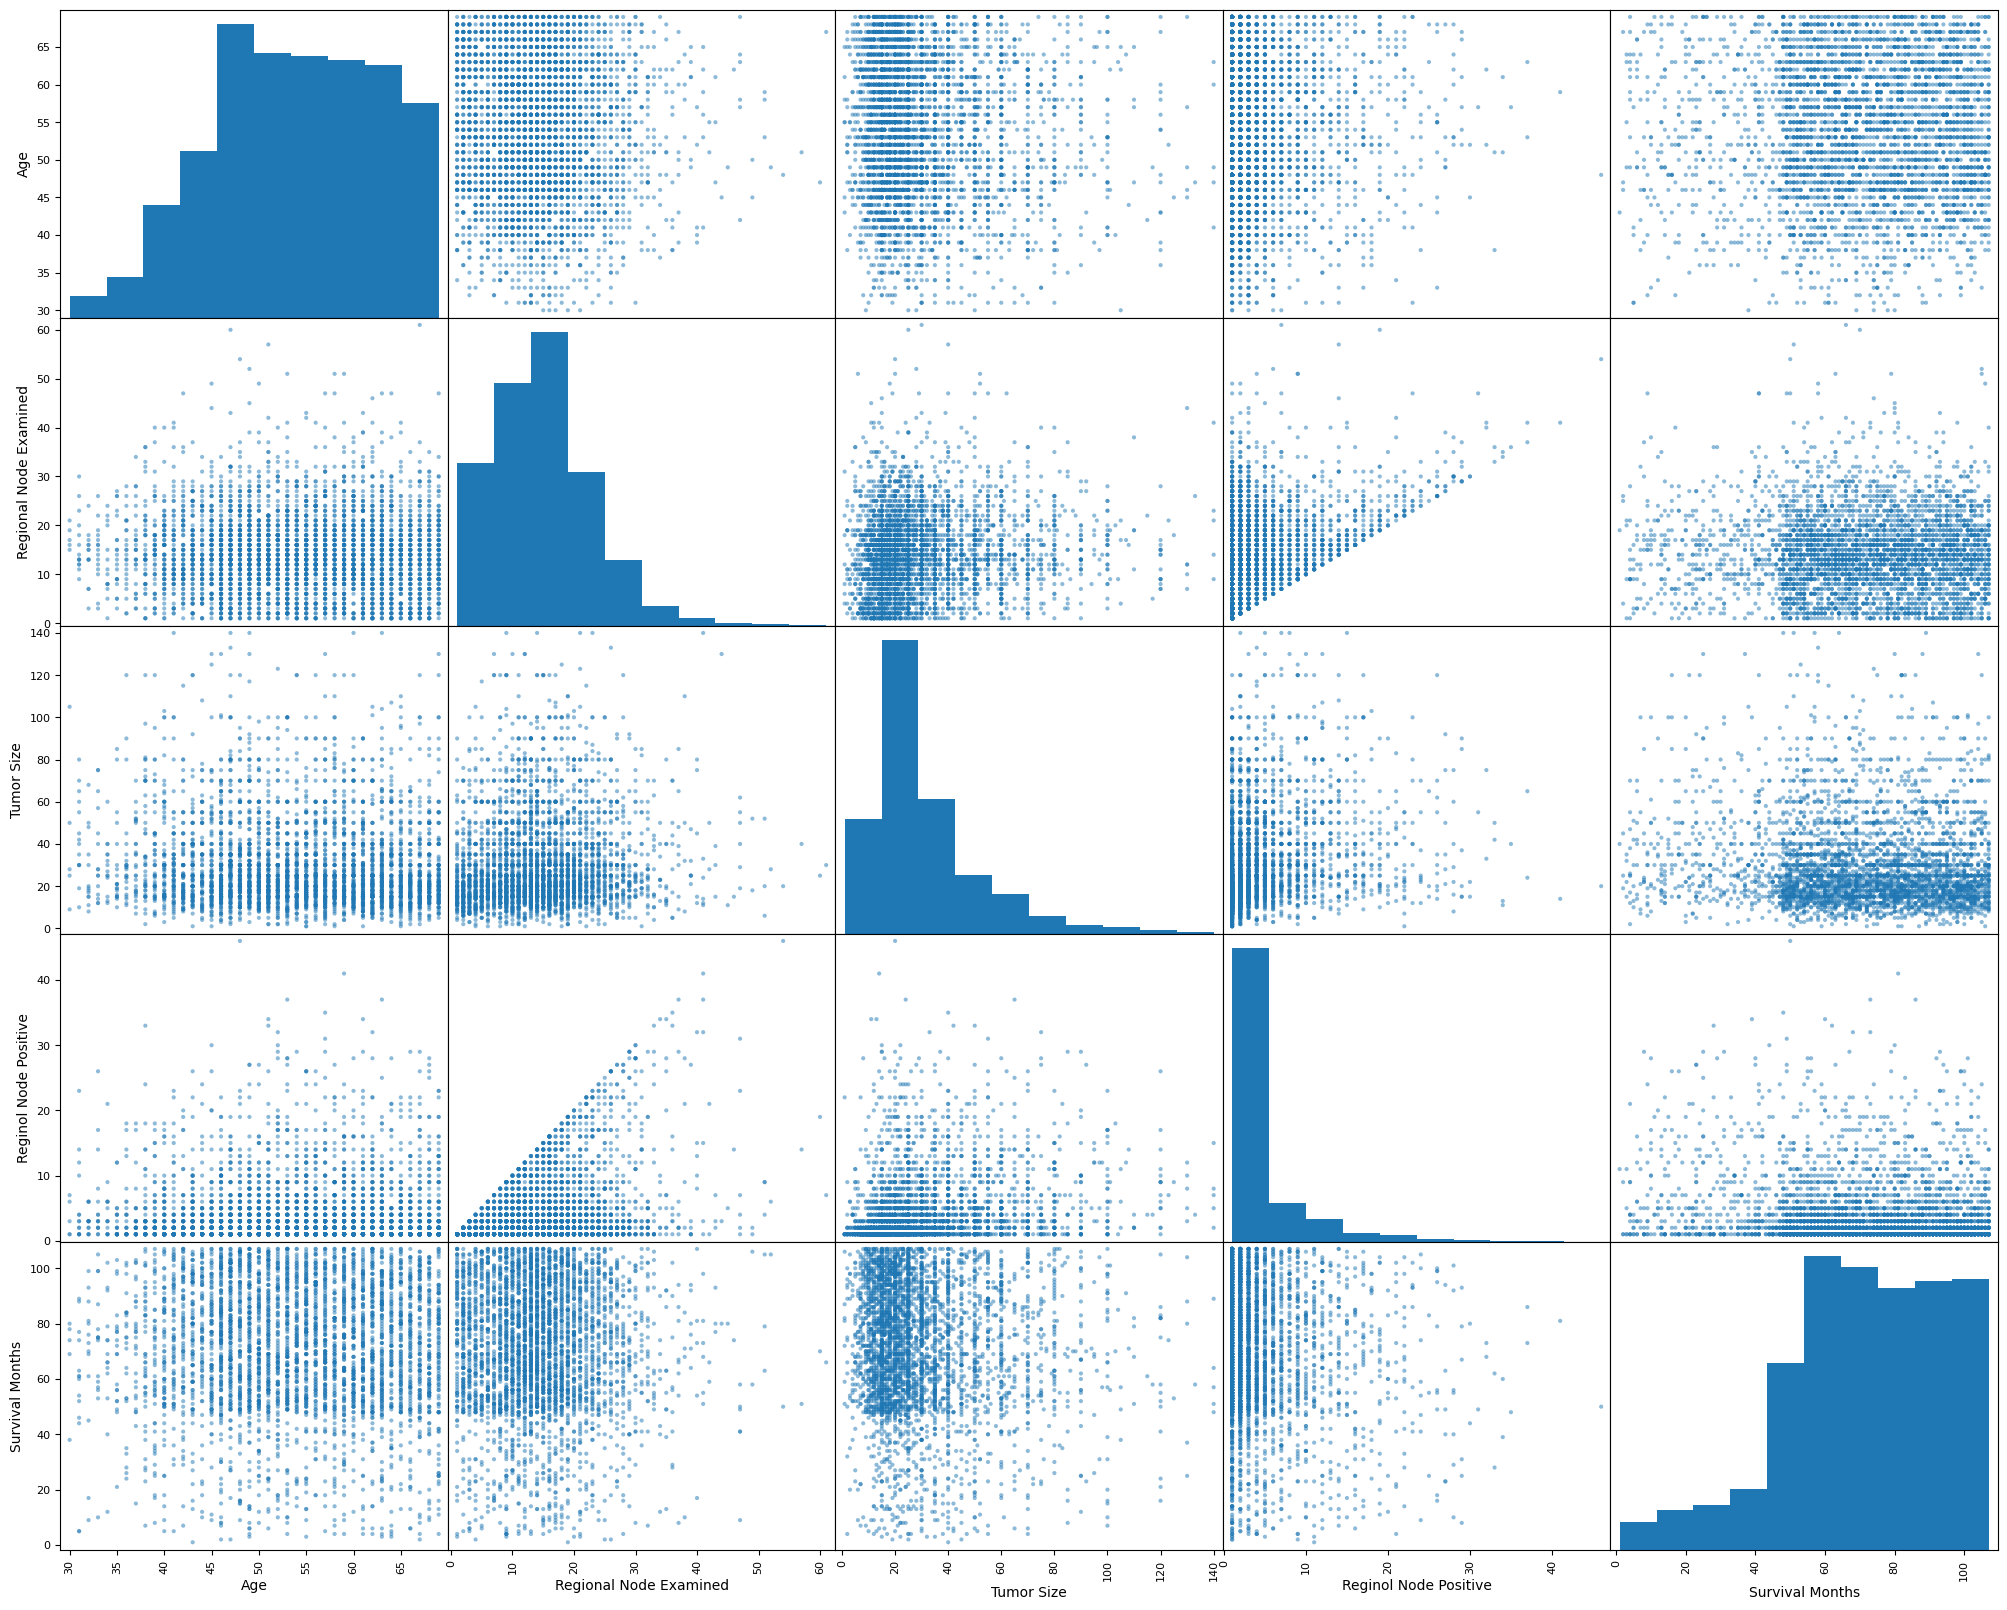

In [28]:
attributes = ["Age","Regional Node Examined","Tumor Size","Reginol Node Positive","Survival Months"]
scatter_matrix(data[attributes], figsize=(25,20))
plt.show()

## Scatterplot and box for data cleaning


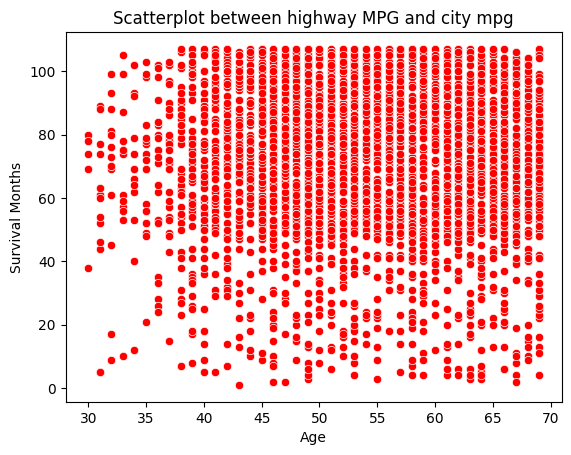

In [29]:
sns.scatterplot(x = 'Age', y = 'Survival Months', data = data, color = 'r')
plt.title("Scatterplot between highway MPG and city mpg")
plt.show()

<Axes: ylabel='Age'>

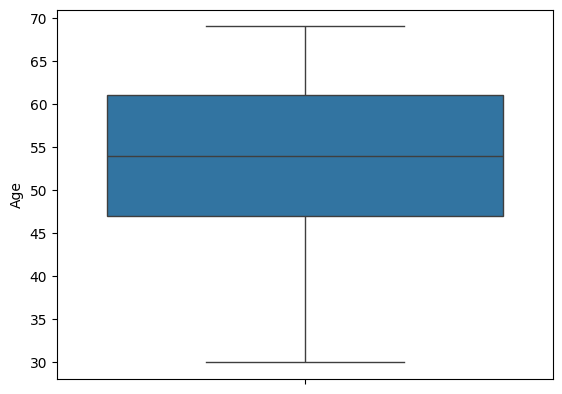

In [30]:
sns.boxplot(data["Age"])

<Axes: ylabel='Regional Node Examined'>

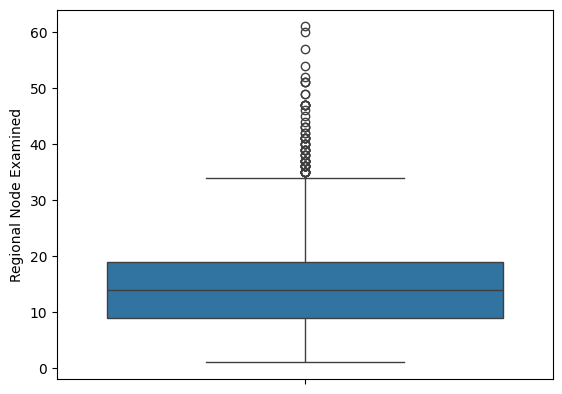

In [31]:
sns.boxplot(data["Regional Node Examined"])

<Axes: ylabel='Regional Node Examined'>

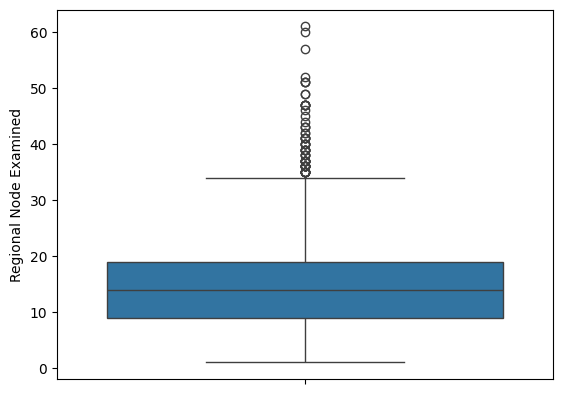

In [32]:
data = data[data["Reginol Node Positive"] < 40]
sns.boxplot(data["Regional Node Examined"])

<Axes: ylabel='Reginol Node Positive'>

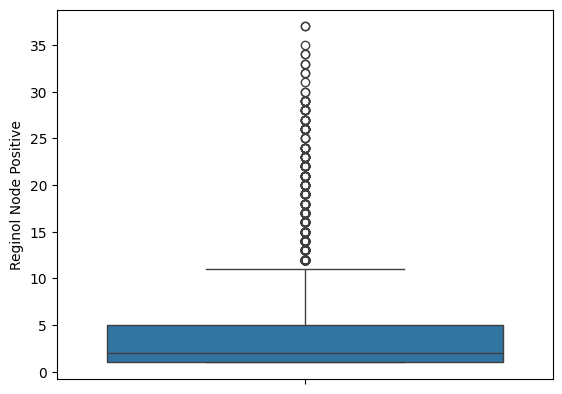

In [33]:
sns.boxplot(data["Reginol Node Positive"])


<Axes: ylabel='Reginol Node Positive'>

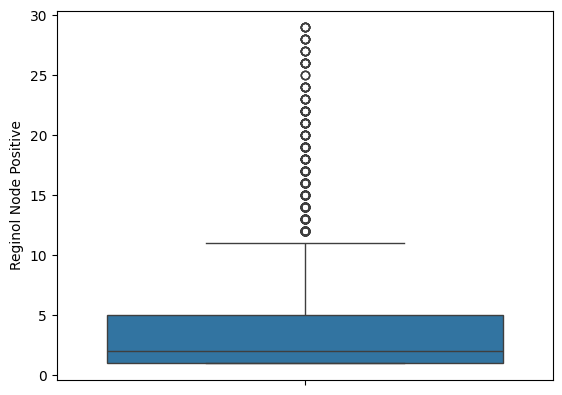

In [34]:
data = data[data["Reginol Node Positive"] < 30]
sns.boxplot(data["Reginol Node Positive"])

<Axes: ylabel='Survival Months'>

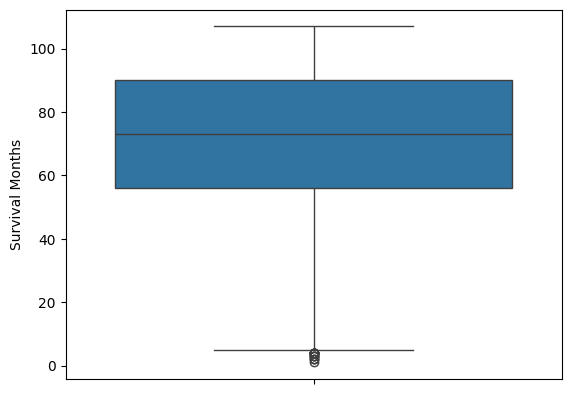

In [35]:
sns.boxplot(data["Survival Months"])

In [36]:
# data = data[data["Survival Months"] > 4]
# sns.boxplot(data["Survival Months"])

<Axes: ylabel='Tumor Size'>

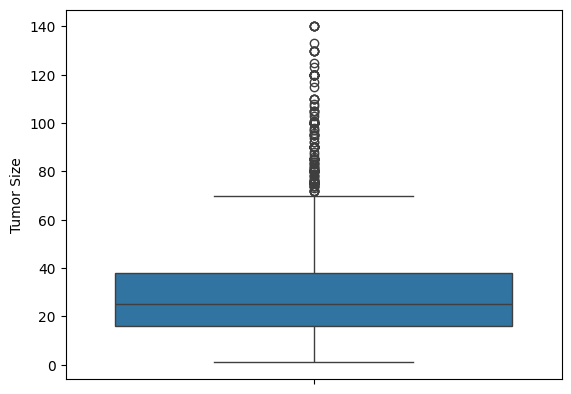

In [37]:
sns.boxplot(data["Tumor Size"])

<Axes: ylabel='Tumor Size'>

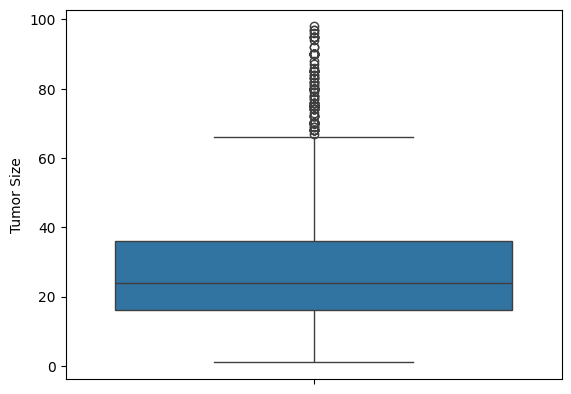

In [38]:
data = data[data["Tumor Size"] < 100]
sns.boxplot(data["Tumor Size"])

## lmplot 

<Figure size 800x800 with 0 Axes>

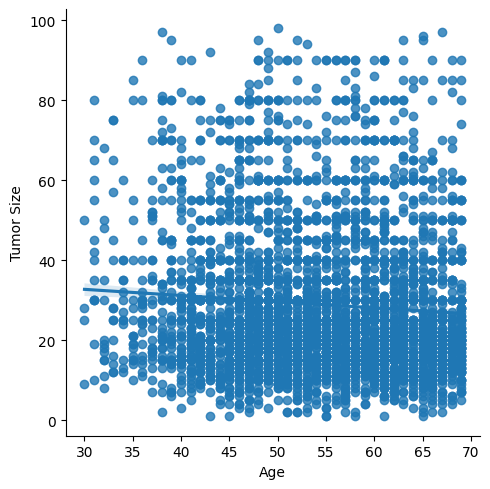

In [39]:
plt.figure(figsize = (8,8))
sns.lmplot(x = 'Age', y = 'Tumor Size', data = data)

<Figure size 800x800 with 0 Axes>

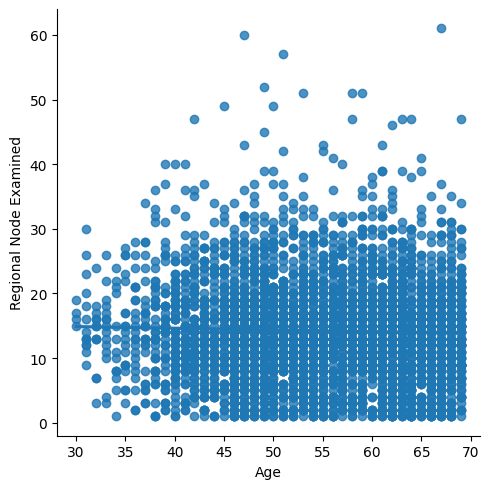

In [40]:
plt.figure(figsize = (8,8))
sns.lmplot(x = 'Age', y = 'Regional Node Examined', data = data)

<Figure size 800x800 with 0 Axes>

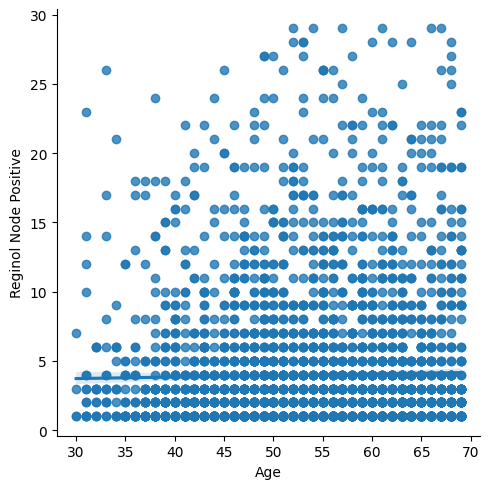

In [41]:
plt.figure(figsize = (8,8))
sns.lmplot(x = 'Age', y = 'Reginol Node Positive', data = data)

<Figure size 800x800 with 0 Axes>

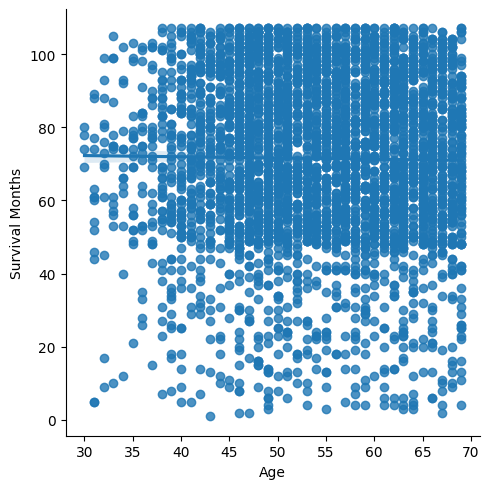

In [42]:
plt.figure(figsize = (8,8))
sns.lmplot(x = 'Age', y = 'Survival Months', data = data)

In [43]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3942 entries, 0 to 4023
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     3942 non-null   int64 
 1   Race                    3942 non-null   object
 2   Marital Status          3942 non-null   object
 3   N Stage                 3942 non-null   object
 4   6th Stage               3942 non-null   object
 5   differentiate           3942 non-null   object
 6   Grade                   3942 non-null   object
 7   A Stage                 3942 non-null   object
 8   Tumor Size              3942 non-null   int64 
 9   Estrogen Status         3942 non-null   object
 10  Progesterone Status     3942 non-null   object
 11  Regional Node Examined  3942 non-null   int64 
 12  Reginol Node Positive   3942 non-null   int64 
 13  Survival Months         3942 non-null   int64 
 14  Status                  3942 non-null   object
dtypes: int64(

## Checking the NULL values and remove or fill

In [44]:
data.isnull().sum() 

Age                       0
Race                      0
Marital Status            0
N Stage                   0
6th Stage                 0
differentiate             0
Grade                     0
A Stage                   0
Tumor Size                0
Estrogen Status           0
Progesterone Status       0
Regional Node Examined    0
Reginol Node Positive     0
Survival Months           0
Status                    0
dtype: int64

## *  one hot encoding

In [45]:
# encoder = OneHotEncoder(sparse_output=False)

# encoder.fit(X_train[["Race", 'Marital Status', 'N Stage', '6th Stage', 'differentiate', 'Grade', 'A Stage', 'Estrogen Status', 'Progesterone Status']])

# one_hot_encoded_output_train = encoder.transform(X_train[["Race", 'Marital Status', 'N Stage', '6th Stage', 'differentiate', 'Grade', 'A Stage', 'Estrogen Status', 'Progesterone Status']])
# one_hot_encoded_output_test = encoder.transform(X_test[["Race", 'Marital Status','N Stage', '6th Stage', 'differentiate', 'Grade', 'A Stage', 'Estrogen Status', 'Progesterone Status']])

# # Get the feature names
# feature_names = encoder.get_feature_names_out(["Race", 'Marital Status', 'N Stage', '6th Stage', 'differentiate', 'Grade', 'A Stage', 'Estrogen Status', 'Progesterone Status'])

# # Create DataFrames from the dense arrays with appropriate column names
# one_hot_encoded_df_train = pd.DataFrame(one_hot_encoded_output_train, columns = feature_names, index=X_train.index)
# one_hot_encoded_df_test = pd.DataFrame(one_hot_encoded_output_test, columns = feature_names, index=X_test.index)

# # Concatenate the DataFrames
# X_train = pd.concat([X_train, one_hot_encoded_df_train], axis=1)
# X_test = pd.concat([X_test, one_hot_encoded_df_test], axis=1)

# # Now you can drop the original categorical columns if desired
# X_train = X_train.drop(columns=["Race", 'Marital Status','N Stage', '6th Stage', 'differentiate', 'Grade', 'A Stage', 'Estrogen Status', 'Progesterone Status'])
# X_test = X_test.drop(columns=["Race", 'Marital Status', 'N Stage', '6th Stage', 'differentiate', 'Grade', 'A Stage', 'Estrogen Status', 'Progesterone Status'])


In [46]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3219 entries, 3714 to 1035
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     3219 non-null   int64 
 1   Race                    3219 non-null   object
 2   Marital Status          3219 non-null   object
 3   N Stage                 3219 non-null   object
 4   6th Stage               3219 non-null   object
 5   differentiate           3219 non-null   object
 6   Grade                   3219 non-null   object
 7   A Stage                 3219 non-null   object
 8   Tumor Size              3219 non-null   int64 
 9   Estrogen Status         3219 non-null   object
 10  Progesterone Status     3219 non-null   object
 11  Regional Node Examined  3219 non-null   int64 
 12  Reginol Node Positive   3219 non-null   int64 
 13  Survival Months         3219 non-null   int64 
dtypes: int64(5), object(9)
memory usage: 377.2+ KB


In [47]:
X_train.head()

,Age,Race,Marital Status,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months
3714,60,White,Divorced,N2,IIIA,Moderately differentiated,2,Regional,44,Positive,Positive,11,7,58
4017,46,White,Married,N1,IIB,Moderately differentiated,2,Regional,28,Negative,Negative,2,1,19
3545,43,White,Married,N1,IIA,Moderately differentiated,2,Regional,20,Positive,Positive,9,1,56
3223,49,Black,Single,N1,IIA,Poorly differentiated,3,Regional,15,Positive,Positive,1,1,61
2669,57,White,Married,N2,IIIA,Moderately differentiated,2,Regional,75,Positive,Positive,13,4,88


## DecisionTreeRegressor

In [48]:
# model = DecisionTreeRegressor(splitter = 'random')
# model.fit(X_train, Y_train)

# Y_predict = model.predict(X_test)

In [49]:
# Y_predict = pd.DataFrame(Y_predict, columns = ['Predicted Output'])
# Y_test = pd.Series(Y_test, name='Actual Output')
# results = pd.concat([Y_predict, Y_test.reset_index(drop=True)], axis=1)

# plt.figure(figsize = (10, 10))
# sns.regplot(data = results, y = 'Predicted Output', x = 'Actual Output', color = 'coral', marker = 'o')
# plt.title("Comparision of predicted values and the actual values", fontsize = 20)
# plt.show()

In [50]:
# print(accuracy_score(Y_predict,Y_test))

# # 0.8397515527950311

In [51]:
# print("MSE:", mean_squared_error(Y_test, Y_predict))
# print("MAE:", mean_absolute_error(Y_test, Y_predict))
# print("R² Score:", r2_score(Y_test, Y_predict))

# # MSE: 0.16024844720496895
# # MAE: 0.16024844720496895
# # R² Score: -0.08510971786833865

## KNeighborsClassifier

In [52]:
# model = KNeighborsClassifier(n_neighbors = 2)
# model.fit(X_train, Y_train)

# Y_predict = model.predict(X_test)

In [53]:
# Y_predict = pd.DataFrame(Y_predict, columns = ['Predicted Output'])
# Y_test = pd.Series(Y_test, name='Actual Output')
# results = pd.concat([Y_predict, Y_test.reset_index(drop=True)], axis=1)

# plt.figure(figsize = (10, 10))
# sns.regplot(data = results, y = 'Predicted Output', x = 'Actual Output', color = 'coral', marker = 'o')
# plt.title("Comparision of predicted values and the actual values", fontsize = 20)
# plt.show()

In [54]:
# print(accuracy_score(Y_predict,Y_test))

# # 0.8695652173913043

In [55]:
# print("MSE:", mean_squared_error(Y_test, Y_predict))
# print("MAE:", mean_absolute_error(Y_test, Y_predict))
# print("R² Score:", r2_score(Y_test, Y_predict))

# # MSE: 0.13043478260869565
# # MAE: 0.13043478260869565
# # R² Score: 0.11677115987460807

## LogisticRegression

In [56]:
# model = LogisticRegression()
# model.fit(X_train, Y_train)  

# Y_predict = model.predict(X_test)

In [57]:
# Y_predict = pd.DataFrame(Y_predict, columns = ['Predicted Output'])
# Y_test = pd.Series(Y_test, name='Actual Output')
# results = pd.concat([Y_predict, Y_test.reset_index(drop=True)], axis=1)

# plt.figure(figsize = (10, 10))
# sns.regplot(data = results, y = 'Predicted Output', x = 'Actual Output', color = 'coral', marker = 'o')
# plt.title("Comparision of predicted values and the actual values", fontsize = 20)
# plt.show()

In [58]:
# print(accuracy_score(Y_predict,Y_test))

# # 0.8832298136645963

In [59]:
# print("MSE:", mean_squared_error(Y_test, Y_predict))
# print("MAE:", mean_absolute_error(Y_test, Y_predict))
# print("R² Score:", r2_score(Y_test, Y_predict))

# # MSE: 0.11677018633540373
# # MAE: 0.11677018633540373
# # R² Score: 0.20929989550679196

# SVC

In [60]:
# model = SVC()
# model.fit(X_train, Y_train)

# Y_predict = model.predict(X_test)

In [61]:
# Y_predict = pd.DataFrame(Y_predict, columns = ['Predicted Output'])
# Y_test = pd.Series(Y_test, name='Actual Output')
# results = pd.concat([Y_predict, Y_test.reset_index(drop=True)], axis=1)

# plt.figure(figsize = (10, 10))
# sns.regplot(data = results, y = 'Predicted Output', x = 'Actual Output', color = 'coral', marker = 'o')
# plt.title("Comparision of predicted values and the actual values", fontsize = 20)
# plt.show()

In [62]:
# print(accuracy_score(Y_predict,Y_test))

# # 0.8695652173913043

In [63]:
# print("MSE:", mean_squared_error(Y_test, Y_predict))
# print("MAE:", mean_absolute_error(Y_test, Y_predict))
# print("R² Score:", r2_score(Y_test, Y_predict))

# # MSE: 0.13043478260869565
# # MAE: 0.13043478260869565
# # R² Score: 0.11677115987460807

# XGBRegressor

In [64]:
# model = XGBRegressor()
# model.fit(X_train, Y_train)

# Y_predict = model.predict(X_test)

In [65]:
# Y_predict = pd.DataFrame(Y_predict, columns = ['Predicted Output'])
# Y_test = pd.Series(Y_test, name='Actual Output')
# results = pd.concat([Y_predict, Y_test.reset_index(drop=True)], axis=1)

# plt.figure(figsize = (10, 10))
# sns.regplot(data = results, y = 'Predicted Output', x = 'Actual Output', color = 'coral', marker = 'o')
# plt.title("Comparision of predicted values and the actual values", fontsize = 20)
# plt.show()

In [66]:
# print("MSE:", mean_squared_error(Y_test, Y_predict))
# print("MAE:", mean_absolute_error(Y_test, Y_predict))
# print("R² Score:", r2_score(Y_test, Y_predict))

# # MSE: 0.09403390702042876
# # MAE: 0.17336850595754147
# # R² Score: 0.3632568171691395

In [67]:
categorical_features = ["Race", "Marital Status", "N Stage", "6th Stage", "differentiate",
                        "Grade", "A Stage", "Estrogen Status", "Progesterone Status"]

# Define columns that should NOT be treated as numeric
exclude_non_numeric = categorical_features + ['Age Group', 'Tumor Size Group', 'Survival Group']

# Automatically identify numeric features
numeric_features = [col for col in X_train.columns if col not in exclude_non_numeric]

# Define column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        ('num', StandardScaler(), numeric_features)
    ]
)

# Create pipeline  
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression())
])

pipeline.fit(X_train, Y_train)

Y_pred = pipeline.predict(X_test)

In [68]:
accuracy = accuracy_score(Y_test, Y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8807453416149068


In [69]:
new_data = pd.DataFrame({
    "Race": ["White"],
    "Marital Status": ["ingli"],
    "N Stage": ["N3"],
    "6th Stage": ["IIIB"],
    "differentiate": ["poorly differentiated"],
    "Grade": ["3"],
    "A Stage": ["Regional"],
    "Estrogen Status": ["Positive"],
    "Progesterone Status": ["Positive"],
    "Age": [50],
    "Tumor Size": [15],
    "Reginol Node Positive": [1],      
    "Survival Months": [1],
    "Regional Node Examined": [4]
})


In [70]:
prediction = pipeline.predict(new_data)
print("Prediction:", prediction)


Prediction: [1]
